In [1]:
import numpy as np
import pint

from jablonski import (
    SingletState,
    SpectroscopicSystem,
    initial,
    transitions,
)
from jablonski.plots.plots import graph_spectra
from jablonski.simulation import (
    emission_spectra,
    excitation_emission_matrix,
    excitation_spectra,
    widened_emission_spectra,
)
from jablonski.sweeps import (
    sweep_emission_spectra,
    sweep_spectral_steady_state_emission,
)

u = pint.get_application_registry()
E0 = -13.6 * u.eV


class Hydrogen(SpectroscopicSystem):
    n2: SingletState = initial(E0 / 2**2, "singlet", default=1)
    n3: SingletState = initial(E0 / 3**2, "singlet", default=0)
    n4: SingletState = initial(E0 / 4**2, "singlet", default=0)
    n5: SingletState = initial(E0 / 5**2, "singlet", default=0)
    n6: SingletState = initial(E0 / 6**2, "singlet", default=0)

    absorption_1 = transitions.Absorption(ground=n2, excited=n3, rate=1.7e-2 * u.cm**2)
    absorption_2 = transitions.Absorption(ground=n2, excited=n4, rate=3.6e-3 * u.cm**2)
    absorption_3 = transitions.Absorption(ground=n2, excited=n5, rate=1.18e-3 * u.cm**2)
    absorption_4 = transitions.Absorption(ground=n2, excited=n6, rate=5.81e-4 * u.cm**2)
    emission_1 = transitions.Fluorescence(ground=n2, excited=n3, rate=4.4e7 / u.s)
    emission_2 = transitions.Fluorescence(ground=n2, excited=n4, rate=8.4e6 / u.s)
    emission_3 = transitions.Fluorescence(ground=n2, excited=n5, rate=3.2e6 / u.s)
    emission_4 = transitions.Fluorescence(ground=n2, excited=n6, rate=1.5e7 / u.s)

In [2]:
# Steady state spectra with at a certain constant excitation
spectra = emission_spectra(
    Hydrogen,
    [
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    height=1e8 / (u.cm**2 * u.s),
)
spectra

Magnitude,[1514825.0044380717 320786.4715276021 105146.6767870665 51771.37221047449]
Units,nanometer


c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


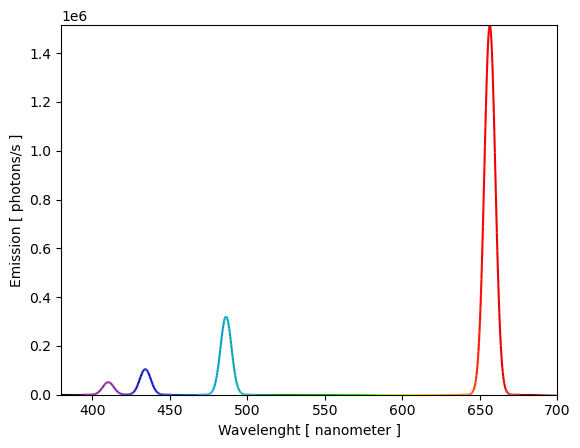

In [3]:
# Graph spectra with an arbitrary linewidth
fig, ax = graph_spectra(
    Hydrogen,
    [
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    height=1e8 / (u.cm**2 * u.s),
)

In [4]:
# We can get the points in the graph with widened_emission_spectra
widened_emission_spectra(
    Hydrogen,
    [
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    height=1e8 / (u.cm**2 * u.s),
)

<xarray.DataArray 'spectrum' (wavelenght: 1000)> Size: 8kB
<Quantity([6.70514458e-012 1.44940289e-011 3.10745777e-011 6.60779375e-011
 1.39361514e-010 2.91517323e-010 6.04812853e-010 1.24455126e-009
 2.54003500e-009 5.14164095e-009 1.03228335e-008 2.05556510e-008
 4.05974430e-008 7.95245572e-008 1.54503731e-007 2.97722610e-007
 5.69009865e-007 1.07860619e-006 2.02787487e-006 3.78141666e-006
 6.99363633e-006 1.28288194e-005 2.33402482e-005 4.21171896e-005
 7.53786630e-005 1.33805082e-004 2.35576477e-004 4.11364083e-004
 7.12452557e-004 1.22382878e-003 2.08506938e-003 3.52334759e-003
 5.90507753e-003 9.81591641e-003 1.61834545e-002 2.64634673e-002
 4.29197707e-002 6.90403802e-002 1.10149895e-001 1.74301104e-001
 2.73559196e-001 4.25831351e-001 6.57444476e-001 1.00673615e+000
 1.52899962e+000 2.30321365e+000 3.44109140e+000 5.09909758e+000
 7.49420506e+000 1.09242833e+001 1.57941213e+001 2.26481701e+001
 3.22111256e+001 4.54374361e+001 6.35706814e+001 8.82134992e+001
 1.21408297e+002 1.65728353e+002 2.24378065e+002 3.01299989e+002
 4.01285036e+002 5.30080647e+002 6.94490110e+002 9.02454502e+002
 1.16310708e+003 1.48678858e+003 1.88501091e+003 2.37035641e+003
 2.95630045e+003 3.65694661e+003 4.48666666e+003 5.45964145e+003
 6.58930444e+003 7.88769589e+003 9.36474327e+003 1.10274914e+004
 1.28793134e+004 1.49191414e+004 1.71407603e+004 1.95322137e+004
...
 2.27924621e+000 1.41990891e+000 8.77333803e-001 5.37655848e-001
 3.26797720e-001 1.97010238e-001 1.17796858e-001 6.98576146e-002
 4.10893177e-002 2.39706186e-002 1.38696240e-002 7.95949044e-003
 4.53044620e-003 2.55759529e-003 1.43204875e-003 7.95277900e-004
 4.38041401e-004 2.39302116e-004 1.29662100e-004 6.96810518e-005
 3.71408190e-005 1.96346602e-005 1.02950968e-005 5.35392910e-006
 2.76153104e-006 1.41274043e-006 7.16819738e-007 3.60738644e-007
 1.80057210e-007 8.91381253e-008 4.37674869e-008 2.13144857e-008
 1.02951633e-008 4.93204184e-009 2.34344842e-009 1.10438165e-009
 5.16200113e-010 2.39305204e-010 1.10032587e-010 5.01794202e-011
 2.26968238e-011 1.01821542e-011 4.53053389e-012 1.99937488e-012
 8.75133309e-013 3.79917527e-013 1.63583531e-013 6.98594175e-014
 2.95900348e-014 1.24308586e-014 5.17954854e-015 2.14051277e-015
 8.77362106e-016 3.56676959e-016 1.43815724e-016 5.75139005e-017
 2.28125800e-017 8.97451776e-018 3.50173254e-018 1.35515807e-018
 5.20154155e-019 1.98020121e-019 7.47690230e-020 2.80007216e-020
 1.04004438e-020 3.83150730e-021 1.39998240e-021 5.07353459e-022
 1.82361775e-022 6.50117906e-023 2.29871738e-023 8.06146855e-024
 2.80399918e-024 9.67334626e-025 3.30986834e-025 1.12325882e-025
 3.78080335e-026 1.26218634e-026 4.17924655e-027 1.37248512e-027], 'nanometer')>
Coordinates:
  * wavelenght  (wavelenght) float64 8kB 380.0 380.3 380.6 ... 699.4 699.7 700.0

In [5]:
# Excitation spectra, calculates steady state emission spectra when exciting all pumpers (one at a time)
# with specified height
excitation_emission_matrix(Hydrogen, height=1e8 / (u.cm**2 * u.s))

Magnitude,[1636761.487991237 0.0 0.0 0.0]
Units,nanometer
Magnitude,[0.0 345205.479457995 0.0 0.0]
Units,nanometer
Magnitude,[0.0 0.0 113803.4960837424 0.0]
Units,nanometer
Magnitude,[0.0 0.0 0.0 57875.827628091545]
Units,nanometer


In [6]:
# Emission at a certain wavelength with different excitations
wavelenght = spectra.coords["wavelenght"][0].item()
excitation_spectra(Hydrogen, emission=wavelenght, height=1e8 / (u.cm**2 * u.s))

Magnitude,[1636761.487991237 0.0 0.0 0.0]
Units,nanometer


In [7]:
# Sweep spectral steady state emission
emission_sweep = sweep_spectral_steady_state_emission(
    Hydrogen,
    excitation_transition=[
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    heights=np.linspace(1e7 / (u.cm**2 * u.s), 1e10 / (u.cm**2 * u.s), 10),
    join_by_energy=True,
)
emission_sweep

Magnitude,[167946.98515211124 35565.24391435312 11657.496652354452 5739.835198421481]
Units,1/second
Magnitude,[8036778.029422646 1701905.9353130558 557846.9466165212 274668.70792879624]
Units,1/second
Magnitude,[10174468.850029847 2154593.403477663 706227.83796957 347727.43540084135]
Units,1/second
Magnitude,[11170837.885558467 2365589.198949934 775387.5716549525 381779.8124234826]
Units,1/second
Magnitude,[11747328.783083662 2487669.6246311576 815402.8214606827 401482.2366442359]
Units,1/second
Magnitude,[12123161.219754476 2567257.6700485414 841490.0141124736 414326.8628624751]


<Axes: xlabel='wavelenght'>

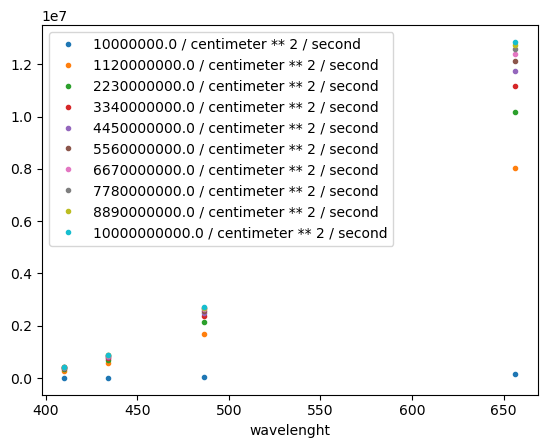

In [8]:
# Sweep emission spectra
spectra_sweep = sweep_emission_spectra(
    Hydrogen,
    excitation_transition=[
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    heights=np.linspace(1e7 / (u.cm**2 * u.s), 1e10 / (u.cm**2 * u.s), 10),
)
spectra_sweep.pint.dequantify().to_dataframe().plot(style=".")